# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

There are 17 campaigns included in the dataset.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import pandas as pd

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [4]:
## Check dataframe information - data types, shape, null values, etc.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [5]:
## No null values, 41188 rows, 21 columns
# ## Drop duration which is unknown before the call
df.drop('duration', axis = 1, inplace = True)

In [6]:
## Check default, housing, and loan columns for class imbalance and potential imputation
print(df['default'].value_counts()/len(df))
print(df['housing'].value_counts()/len(df))
print(df['loan'].value_counts()/len(df))

default
no         0.791201
unknown    0.208726
yes        0.000073
Name: count, dtype: float64
housing
yes        0.523842
no         0.452122
unknown    0.024036
Name: count, dtype: float64
loan
no         0.824269
yes        0.151695
unknown    0.024036
Name: count, dtype: float64


In [7]:
## default has siginificant class imbalance; the majorrity is 'no' (~79%), 'unknown' pretty much fills the rest (~21%) and 'yes' is less than 0.1%
## mapping this to known: 1, unknown: 0
df['default'] = df['default'].map({'yes': 1, 'no': 1, 'unknown': 0})

## housing and loan have 2.4% unkown, fill with median
df['housing'] = df['housing'].map({'yes': 1, 'no': 0})
df['housing'] = df['housing'].fillna(df['housing'].median())
df['loan'] = df['loan'].map({'yes': 1, 'no': 0})
df['loan'] = df['loan'].fillna(df['loan'].median())

In [8]:
## check dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  int64  
 5   housing         41188 non-null  float64
 6   loan            41188 non-null  float64
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  poutcome        41188 non-null  str    
 14  emp.var.rate    41188 non-null  float64
 15  cons.price.idx  41188 non-null  float64
 16  cons.conf.idx   41188 non-null  float64
 17  euribor3m       41188 non-null  float64
 1

In [9]:
## Check 'unknown' in categorical features: job, marital, education, contact, month, poutcome
print('Job:')
print(df['job'].value_counts()/len(df))
print('Marital:')
print(df['marital'].value_counts()/len(df))
print('Education:')
print(df['education'].value_counts()/len(df))
print('Contact:')
print(df['contact'].value_counts()/len(df))
print('Month:')
print(df['month'].value_counts()/len(df))
print('Poutcome:')
print(df['poutcome'].value_counts()/len(df))

## 'unknown' is a valid category for job, martial and education; will use onehot encoding


Job:
job
admin.           0.253035
blue-collar      0.224677
technician       0.163713
services         0.096363
management       0.070992
retired          0.041760
entrepreneur     0.035350
self-employed    0.034500
housemaid        0.025736
unemployed       0.024619
student          0.021244
unknown          0.008012
Name: count, dtype: float64
Marital:
marital
married     0.605225
single      0.280859
divorced    0.111974
unknown     0.001942
Name: count, dtype: float64
Education:
education
university.degree      0.295426
high.school            0.231014
basic.9y               0.146766
professional.course    0.127294
basic.4y               0.101389
basic.6y               0.055647
unknown                0.042027
illiterate             0.000437
Name: count, dtype: float64
Contact:
contact
cellular     0.634748
telephone    0.365252
Name: count, dtype: float64
Month:
month
may    0.334296
jul    0.174177
aug    0.149995
jun    0.129115
nov    0.099568
apr    0.063902
oct    0.017432
sep

In [10]:
## Check numerical features distribution and statistics
df.describe()

,age,default,housing,loan,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,0.791274,0.547878,0.151695,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,0.406403,0.497708,0.358729,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,1.000000,0.000000,0.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,1.000000,1.000000,0.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,1.000000,1.000000,0.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,1.000000,1.000000,1.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


array([[<Axes: title={'center': 'age'}>]], dtype=object)

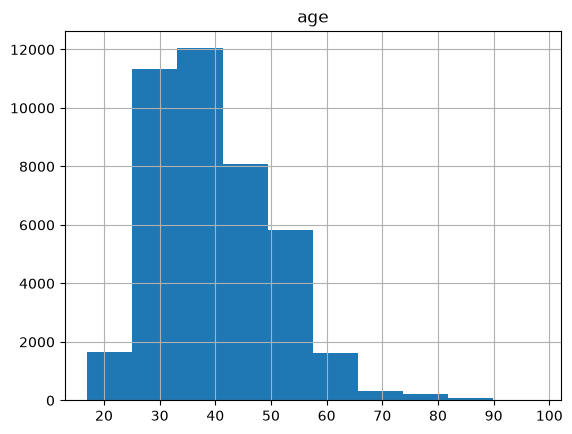

In [11]:
## Check for outliers in numerical features: age
df[['age']].hist()

In [12]:
df.sort_values(by='age', ascending=False).head(10)

## Age is skewed to the left with a long tail to the right but no extreme outliers, keep as-is

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
38452,98,retired,married,basic.4y,0,1.0,0.0,cellular,oct,fri,1,2,2,success,-3.4,92.431,-26.9,0.730,5017.5,yes
38455,98,retired,married,basic.4y,0,1.0,0.0,cellular,oct,fri,2,999,0,nonexistent,-3.4,92.431,-26.9,0.730,5017.5,yes
27826,95,retired,divorced,basic.6y,1,0.0,0.0,cellular,mar,thu,1,999,0,nonexistent,-1.8,92.843,-50.0,1.650,5099.1,no
38921,94,retired,married,basic.9y,1,0.0,0.0,cellular,nov,wed,1,999,1,failure,-3.4,92.649,-30.1,0.716,5017.5,no
39655,92,retired,married,unknown,1,1.0,0.0,cellular,may,thu,1,6,2,success,-1.8,93.876,-40.0,0.683,5008.7,no
40450,92,retired,married,unknown,1,0.0,1.0,cellular,aug,tue,1,3,1,success,-1.7,94.027,-38.3,0.904,4991.6,yes
39734,92,retired,divorced,unknown,0,0.0,0.0,cellular,may,wed,3,999,1,failure,-1.8,93.876,-40.0,0.697,5008.7,yes
40469,92,retired,married,unknown,1,0.0,1.0,cellular,aug,wed,1,3,4,success,-1.7,94.027,-38.3,0.903,4991.6,yes
38032,91,retired,married,university.degree,1,0.0,1.0,cellular,sep,wed,2,999,0,nonexistent,-3.4,92.379,-29.8,0.781,5017.5,no
38022,91,retired,married,university.degree,1,1.0,1.0,cellular,sep,wed,1,999,2,failure,-3.4,92.379,-29.8,0.781,5017.5,no


array([[<Axes: title={'center': 'campaign'}>]], dtype=object)

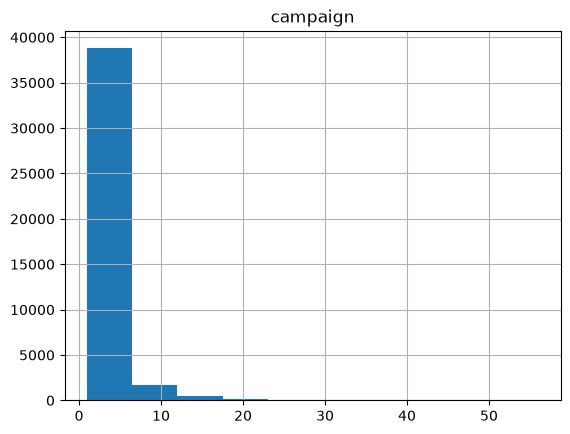

In [13]:
## Check for outliers in numerical features: campaign
df[['campaign']].hist()

In [14]:
df.sort_values(by='campaign', ascending=False).head(10)

## Campaign is significantly skewed to the left with a long tail to the right but still continuous, looks reasonable, keep as-is

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
4107,32,admin.,married,university.degree,0,1.0,0.0,telephone,may,mon,56,999,0,nonexistent,1.1,93.994,-36.4,4.858,5191.0,no
18728,54,admin.,married,university.degree,0,1.0,0.0,cellular,jul,thu,43,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
13447,32,technician,single,university.degree,1,1.0,1.0,telephone,jul,wed,43,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
4168,29,technician,married,professional.course,1,1.0,0.0,telephone,may,mon,42,999,0,nonexistent,1.1,93.994,-36.4,4.858,5191.0,no
5304,44,retired,married,basic.9y,1,1.0,0.0,telephone,may,fri,42,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
11033,38,blue-collar,married,basic.4y,1,1.0,0.0,telephone,jun,wed,41,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
18754,36,admin.,single,university.degree,1,0.0,0.0,cellular,jul,thu,40,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
11769,56,self-employed,married,professional.course,1,0.0,1.0,telephone,jun,fri,40,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4114,52,entrepreneur,married,university.degree,1,0.0,0.0,telephone,may,mon,39,999,0,nonexistent,1.1,93.994,-36.4,4.858,5191.0,no
11593,43,technician,married,high.school,1,1.0,0.0,telephone,jun,fri,37,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no


In [15]:
## pdays has a special value of 999 which means the client was not previously contacted
df['pcontacted'] = df['pdays'].apply(lambda x: 0 if x == 999 else 1)

print(df['pcontacted'].value_counts())
print('------')
print(df['pcontacted'].value_counts()/len(df))

pcontacted
0    39673
1     1515
Name: count, dtype: int64
------
pcontacted
0    0.963217
1    0.036783
Name: count, dtype: float64


<Axes: >

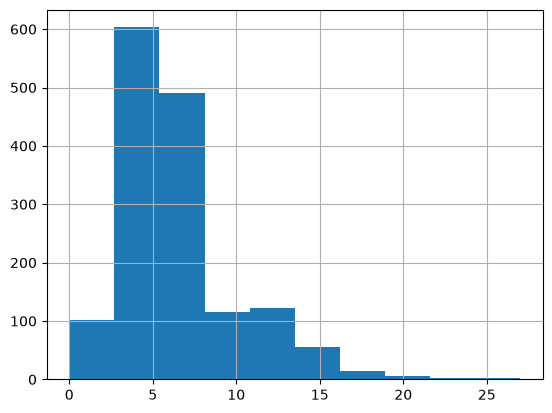

In [16]:
## Check distribution of pdays for clients that were previously contacted
df.where(df['pcontacted'] == 1)['pdays'].hist()

In [17]:
## Dropping pdays - only <4% of clients were previously contacted, and pdays has a fairly focused range of values
df.drop('pdays', axis = 1, inplace = True)

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='whitegrid')

subscribed = (df['y'] == 'yes').astype(int)

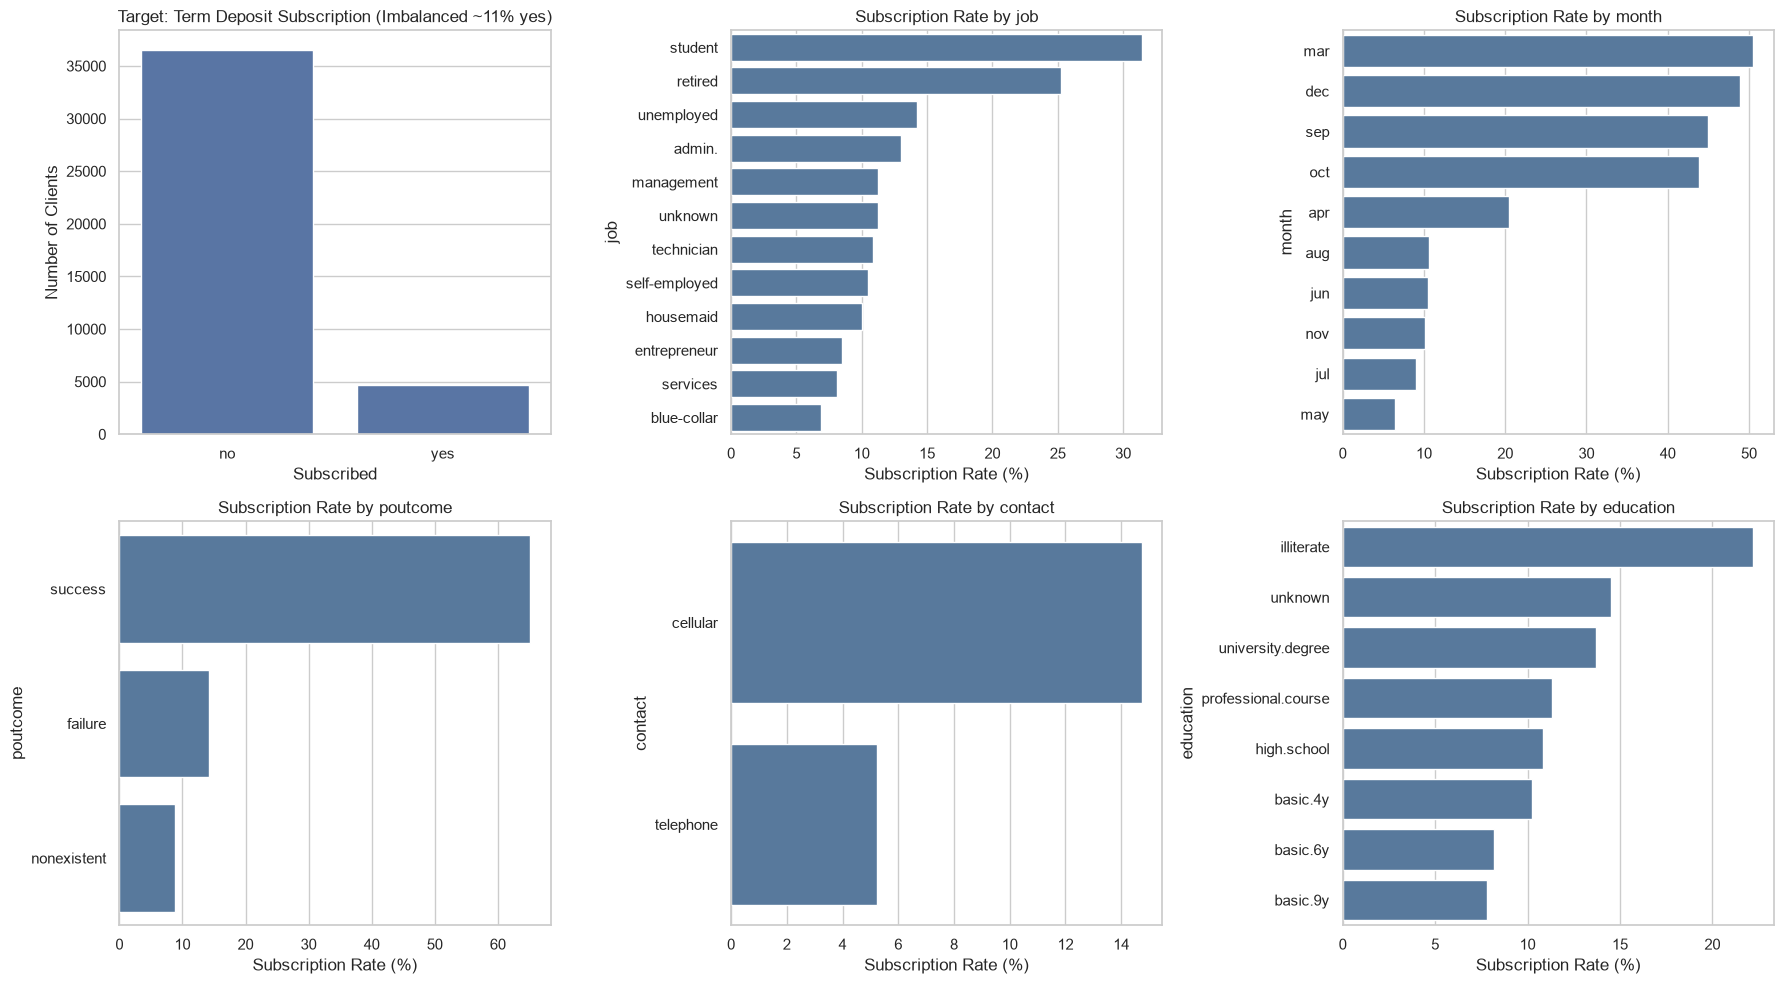

In [19]:
# Visualize the subsciprtion rate by categorical features and the distribution of the target variable
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

order = df['y'].value_counts().index
sns.countplot(x=df['y'], order=order, ax=axes[0])
axes[0].set_title('Target: Term Deposit Subscription (Imbalanced ~11% yes)')
axes[0].set_xlabel('Subscribed'); axes[0].set_ylabel('Number of Clients')

for ax, col in zip(axes[1:], ['job', 'month', 'poutcome', 'contact', 'education']):
    rate = df.assign(sub=subscribed).groupby(col)['sub'].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rate.values, y=rate.index, ax=ax, color='#4C78A8')
    ax.set_title(f'Subscription Rate by {col}')
    ax.set_xlabel('Subscription Rate (%)'); ax.set_ylabel(col)

plt.tight_layout()
plt.show()

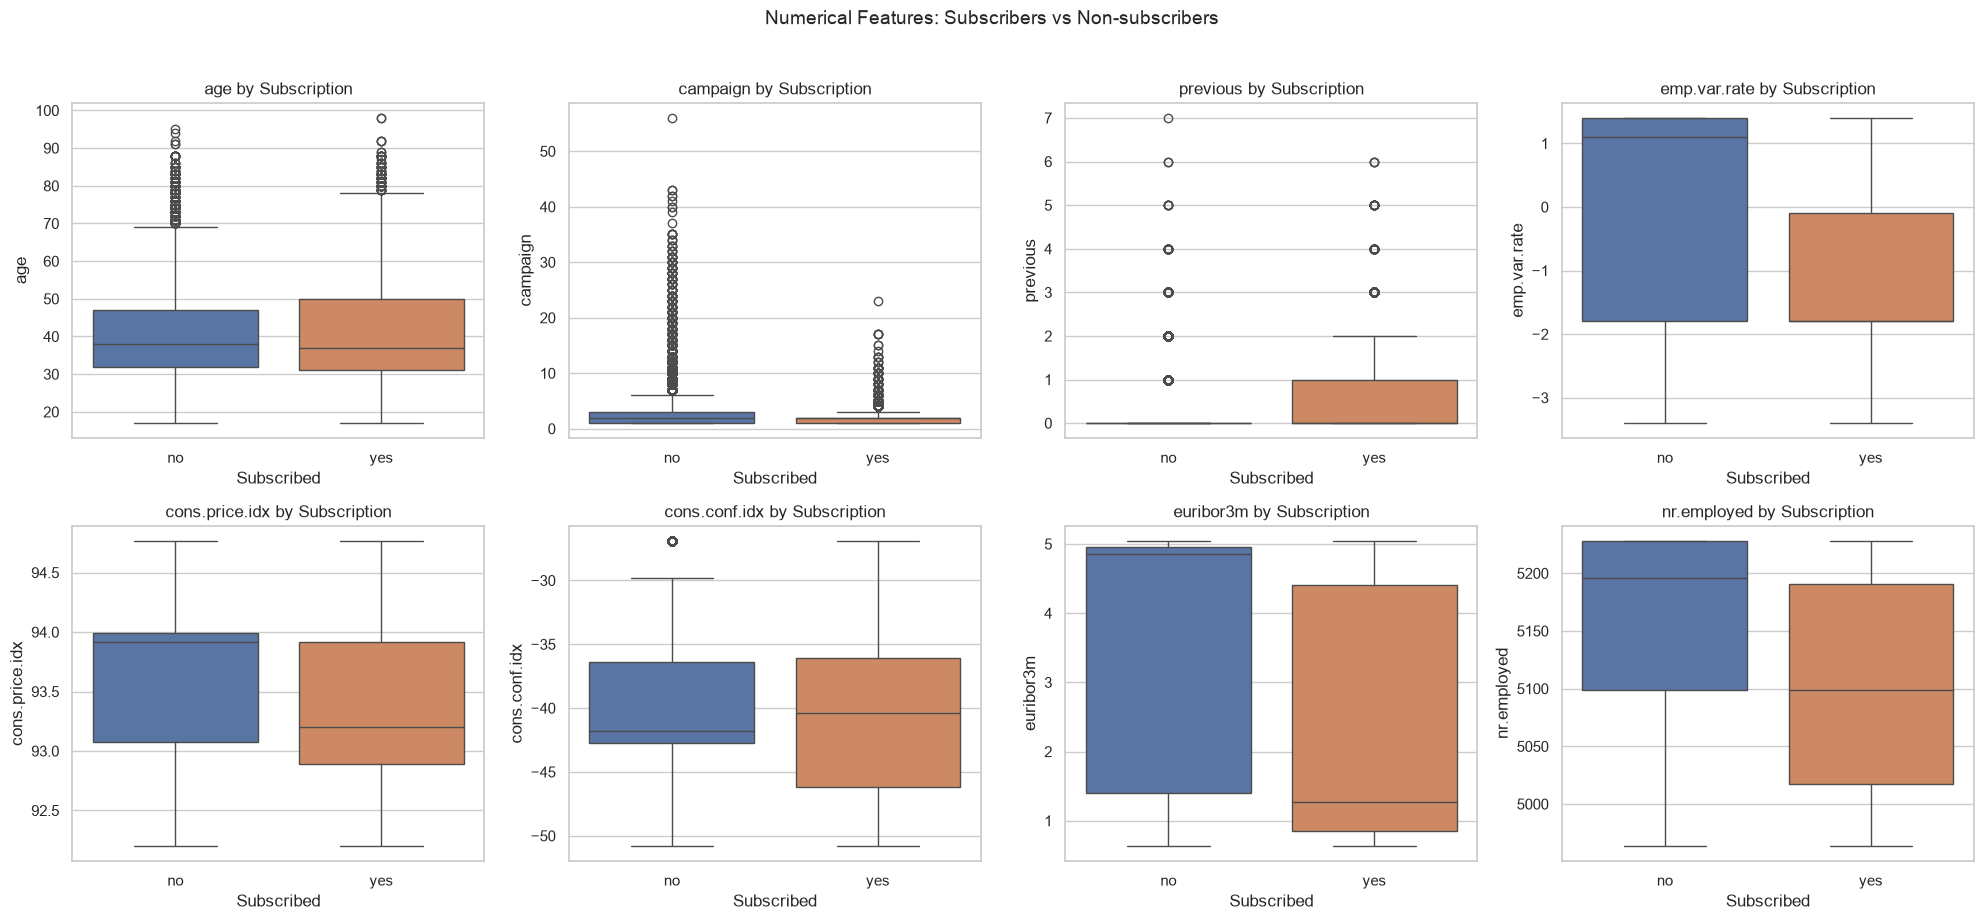

In [20]:
# Visualize the distribution of numerical features by subscription
num_cols = ['age', 'campaign', 'previous', 'emp.var.rate',
            'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x=df['y'], y=df[col], ax=ax, hue=df['y'], legend=False)
    ax.set_title(f'{col} by Subscription')
    ax.set_xlabel('Subscribed'); ax.set_ylabel(col)

plt.suptitle('Numerical Features: Subscribers vs Non-subscribers', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

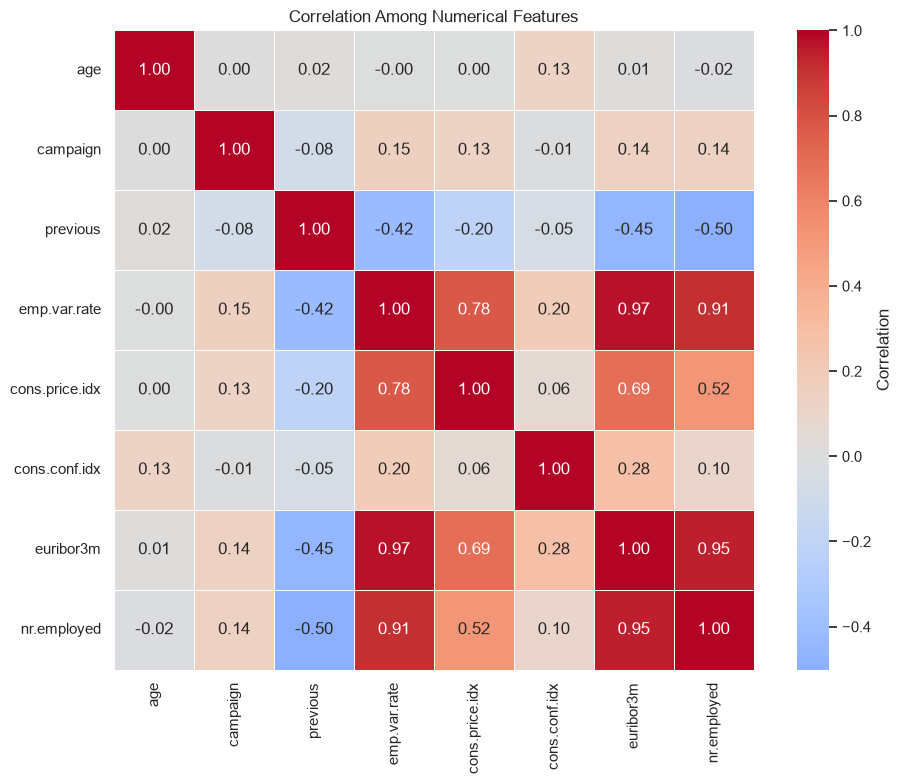

In [21]:
# Visualize the correlation among numerical features
plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Among Numerical Features')
plt.tight_layout()
plt.show()

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

### Data
The dataset contains telephone marketing across 17 campaigns from a bank with 20 features and 'y' - 'y' in this data is whether the client subscribed the term deposit or not.

### Business Problem
Telephone marketing requires call center setup and dedicated marketers which make the method costly. Analyzing the data and features between clients who subscribed vs. not subscribed and have a better understanding who to target can potentially increase the profitability of the campaigns.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [22]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
import time

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

In [23]:
bank_df = df[[ 'age','job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'poutcome', 'pcontacted', 'y']]

bank_cat_features = bank_df.drop('y', axis=1).select_dtypes(include='str').columns
bank_num_features = ['age', 'campaign']

print(f"Bank categorical features: {bank_cat_features}")
print(f"Bank numerical features: {bank_num_features}")

Bank categorical features: Index(['job', 'marital', 'education', 'contact', 'month', 'day_of_week',
       'poutcome'],
      dtype='str')
Bank numerical features: ['age', 'campaign']


In [24]:
lr_pipe = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('num', StandardScaler(), bank_num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), bank_cat_features)
    ], remainder='passthrough')),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [25]:
lr_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, defau

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('y', axis=1),
    df['y'].map({'yes': 1, 'no': 0}),
    test_size=0.2, random_state=42, stratify=df['y']
)
print(X_train.shape, X_test.shape)

(32950, 19) (8238, 19)


In [27]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(32950, 19) (8238, 19) (32950,) (8238,)


In [28]:
X_bank_train, X_bank_test, y_bank_train, y_bank_test = train_test_split(bank_df.drop('y', axis=1), bank_df['y'], test_size=0.2, random_state=42)
print(X_bank_train.shape, X_bank_test.shape, y_bank_train.shape, y_bank_test.shape)

(32950, 13) (8238, 13) (32950,) (8238,)


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [29]:
## Based on results below, the baseline accuracy is 88.7% (the majority outcome is 'no')

df['y'].value_counts(normalize=True)

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [30]:
lr_pipe.fit(X_bank_train, y_bank_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['no','yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['age','job','marital',...,'campaign','poutcome','pcontacted']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, 

### Problem 9: Score the Model

What is the accuracy of your model?

In [31]:
## The Logistic Regression model returns a 89.5% accuracy, which is only 0.8% better than the baseline

lr_pipe.score(X_bank_test, y_bank_test)

0.8953629521728574

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [32]:
cat_features = df.drop('y', axis=1).select_dtypes(include='str').columns
num_features = df.drop(['default','housing','loan','pcontacted'], axis=1).select_dtypes(include='number').columns

print(f"Categorical features: {cat_features}")
print(f"Numerical features: {num_features}")

Categorical features: Index(['job', 'marital', 'education', 'contact', 'month', 'day_of_week',
       'poutcome'],
      dtype='str')
Numerical features: Index(['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='str')


In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first'), cat_features)
    ],
    remainder='passthrough'
)

In [34]:
base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVC': SVC()
}

def pos_scores(est, X):
    if hasattr(est, 'predict_proba'):
        return est.predict_proba(X)[:, 1]
    return est.decision_function(X)

results = []
for name, model in base_models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    start = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - start

    te_pred = pipe.predict(X_test)
    tr_pred = pipe.predict(X_train)
    te_proba = pos_scores(pipe, X_test)
    tr_proba = pos_scores(pipe, X_train)

    results.append({
        'Model': f'{name} (Default)',
        'Train Time (s)': round(train_time, 3),
        'Train Accuracy': round(pipe.score(X_train, y_train), 4),
        'Test Accuracy': round(pipe.score(X_test, y_test), 4),
        'Test Precision': round(precision_score(y_test, te_pred), 4),
        'Test Recall': round(recall_score(y_test, te_pred), 4),
        'Train F1': round(f1_score(y_train, tr_pred), 4),
        'Test F1': round(f1_score(y_test, te_pred), 4),
        'Train ROC AUC': round(roc_auc_score(y_train, tr_proba), 4),
        'Test ROC AUC': round(roc_auc_score(y_test, te_proba), 4)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Train Time (s),Train Accuracy,Test Accuracy,Test Precision,Test Recall,Train F1,Test F1,Train ROC AUC,Test ROC AUC
0,Logistic Regression (Default),0.109,0.8999,0.9013,0.6910,0.2241,0.3393,0.3385,0.7932,0.8009
1,KNN (Default),0.047,0.9134,0.8935,0.5530,0.2866,0.5007,0.3776,0.9255,0.7393
2,Decision Tree (Default),0.321,0.9952,0.8450,0.3264,0.3534,0.9781,0.3394,0.9999,0.6319
3,SVC (Default),28.522,0.9049,0.9031,0.7057,0.2403,0.3792,0.3585,0.8750,0.6993


### Basic Model with Default Setting
- SVC, as expected, takes significantly longer time to train
- Decision Tree has the best accuracy on training data but performs the worst on test data (84.5%, even worse than baseline 88.7%), a clear signal of overfitting
- Logistic Regression, KNN and SVC performance on train and test data are fairly close; however, overall not much better than the baseline

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [35]:

def pos_scores(est, X):
    if hasattr(est, 'predict_proba'):
        return est.predict_proba(X)[:, 1]  
    return est.decision_function(X)

tuned_models = {
    'KNN': (KNeighborsClassifier(),
            {'clf__n_neighbors': [3, 5, 7, 9]}),
    'Logistic Regression': (LogisticRegression(max_iter=1000, class_weight='balanced'),
            {'clf__C': [0.01, 0.1, 1, 10]}),
    'Decision Tree': (DecisionTreeClassifier(random_state=42, class_weight='balanced'),
            {'clf__max_depth': [3, 5, 10, None], 'clf__ccp_alpha': [0.0, 0.001]}),
    'Linear SVC': (LinearSVC(class_weight='balanced', max_iter=5000, dual='auto'),
            {'clf__C': [0.01, 0.1, 1]}),
}

rows = []
for name, (model, grid) in tuned_models.items():
    gs = GridSearchCV(
        Pipeline([('preprocessor', preprocessor), ('clf', model)]),
        param_grid=grid,
        scoring=['accuracy', 'roc_auc', 'f1'],
        refit='f1', cv=5, n_jobs=-1
    )
    t = time.time()
    gs.fit(X_train, y_train)
    fit_time = time.time() - t

    te_pred  = gs.predict(X_test)
    te_score = pos_scores(gs, X_test)

    rows.append({
        'Model': name,
        'Best Params': gs.best_params_,
        'Train Time (s)': round(fit_time, 2),
        'Train Accuracy': round(gs.score(X_train, y_train), 4),
        'Test Accuracy': round(accuracy_score(y_test, te_pred), 4),
        'Test Precision': round(precision_score(y_test, te_pred), 4),
        'Test Recall': round(recall_score(y_test, te_pred), 4),
        'Train F1': round(f1_score(y_train, tr_pred), 4),
        'Test F1': round(f1_score(y_test, te_pred), 4),
        'Test ROC AUC': round(roc_auc_score(y_test, te_score), 4),
    })


In [36]:
comparison_df = pd.concat([results_df, pd.DataFrame(rows)], ignore_index=True)
comparison_df.sort_values('Test F1', ascending=False).reset_index(drop=True)

,Model,Train Time (s),Train Accuracy,Test Accuracy,Test Precision,Test Recall,Train F1,Test F1,Train ROC AUC,Test ROC AUC,Best Params
0,Decision Tree,1.740,0.4570,0.8464,0.3851,0.6088,0.3792,0.4718,NaN,0.7808,"{'clf__ccp_alpha': 0.0, 'clf__max_depth': 3}"
1,Logistic Regression,1.330,0.4525,0.8347,0.3669,0.6444,0.3792,0.4676,NaN,0.8008,{'clf__C': 10}
2,Linear SVC,1.280,0.4511,0.8331,0.3641,0.6455,0.3792,0.4656,NaN,0.8007,{'clf__C': 1}
3,KNN (Default),0.047,0.9134,0.8935,0.5530,0.2866,0.5007,0.3776,0.9255,0.7393,NaN
4,KNN,9.700,0.5007,0.8935,0.5530,0.2866,0.3792,0.3776,NaN,0.7393,{'clf__n_neighbors': 5}
5,SVC (Default),28.522,0.9049,0.9031,0.7057,0.2403,0.3792,0.3585,0.8750,0.6993,NaN
6,Decision Tree (Default),0.321,0.9952,0.8450,0.3264,0.3534,0.9781,0.3394,0.9999,0.6319,NaN
7,Logistic Regression (Default),0.109,0.8999,0.9013,0.6910,0.2241,0.3393,0.3385,0.7932,0.8009,NaN


In [37]:
## Adding PolynomialFeatures to the pipeline for Logistic Regression
from sklearn.preprocessing import PolynomialFeatures

pre_poly = ColumnTransformer([
    ('num', Pipeline([
        ('scale', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2, include_bias=False))
    ]), num_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
], remainder='passthrough')

lr_poly = Pipeline([('preprocessor', pre_poly),
                    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))])

lr_poly

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, defau

In [38]:
## Adding the results to the comparison table
start = time.time()
lr_poly.fit(X_train, y_train)
poly_time = time.time() - start

tr_pred, te_pred   = lr_poly.predict(X_train), lr_poly.predict(X_test)
tr_proba, te_proba = lr_poly.predict_proba(X_train)[:, 1], lr_poly.predict_proba(X_test)[:, 1]

lr_poly_row = {
    'Model': 'LogReg + Poly (balanced)',
    'Best Params': 'degree=2, class_weight=balanced',
    'Train Time (s)': round(poly_time, 3),
    'Train Accuracy': round(accuracy_score(y_train, tr_pred), 4),
    'Test Accuracy':  round(accuracy_score(y_test, te_pred), 4),
    'Test Precision': round(precision_score(y_test, te_pred), 4),
    'Test Recall':    round(recall_score(y_test, te_pred), 4),
    'Train F1': round(f1_score(y_train, tr_pred), 4),
    'Test F1':  round(f1_score(y_test, te_pred), 4),
    'Train ROC AUC': round(roc_auc_score(y_train, tr_proba), 4),
    'Test ROC AUC':  round(roc_auc_score(y_test, te_proba), 4)
}

comparison_df = pd.concat([comparison_df, pd.DataFrame([lr_poly_row])], ignore_index=True)
comparison_df.sort_values(by='Test F1', ascending=False).reset_index(drop=True)

,Model,Train Time (s),Train Accuracy,Test Accuracy,Test Precision,Test Recall,Train F1,Test F1,Train ROC AUC,Test ROC AUC,Best Params
0,LogReg + Poly (balanced),0.698,0.8285,0.8343,0.3683,0.6584,0.4537,0.4724,0.7993,0.8053,"degree=2, class_weight=balanced"
1,Decision Tree,1.740,0.4570,0.8464,0.3851,0.6088,0.3792,0.4718,NaN,0.7808,"{'clf__ccp_alpha': 0.0, 'clf__max_depth': 3}"
2,Logistic Regression,1.330,0.4525,0.8347,0.3669,0.6444,0.3792,0.4676,NaN,0.8008,{'clf__C': 10}
3,Linear SVC,1.280,0.4511,0.8331,0.3641,0.6455,0.3792,0.4656,NaN,0.8007,{'clf__C': 1}
4,KNN (Default),0.047,0.9134,0.8935,0.5530,0.2866,0.5007,0.3776,0.9255,0.7393,NaN
5,KNN,9.700,0.5007,0.8935,0.5530,0.2866,0.3792,0.3776,NaN,0.7393,{'clf__n_neighbors': 5}
6,SVC (Default),28.522,0.9049,0.9031,0.7057,0.2403,0.3792,0.3585,0.8750,0.6993,NaN
7,Decision Tree (Default),0.321,0.9952,0.8450,0.3264,0.3534,0.9781,0.3394,0.9999,0.6319,NaN
8,Logistic Regression (Default),0.109,0.8999,0.9013,0.6910,0.2241,0.3393,0.3385,0.7932,0.8009,NaN


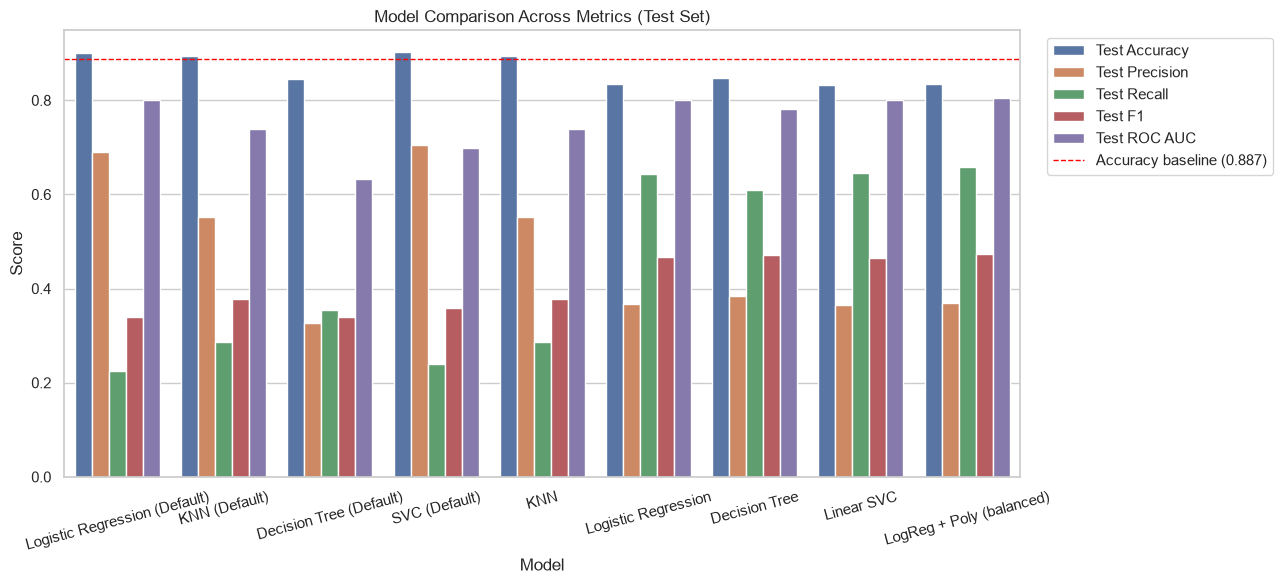

In [39]:
plot_df = comparison_df.melt(
    id_vars='Model',
    value_vars=['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1', 'Test ROC AUC'],
    var_name='Metric', value_name='Score'
)

plt.figure(figsize=(13, 6))
sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric')
plt.title('Model Comparison Across Metrics (Test Set)')
plt.xlabel('Model'); plt.ylabel('Score')
plt.xticks(rotation=15)
plt.axhline(0.887, color='red', ls='--', lw=1, label='Accuracy baseline (0.887)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Findings & Recommendations

### Business Context
A Portuguese bank runs outbound telephone campaigns to sell term-deposit
subscriptions. Calls are costly and only ~11% of contacts subscribe, so the
goal is to help the bank spend its limited calling capacity on the clients
most likely to convert.

### Key Findings

**1. Accuracy is a misleading metric here.**
Because 89% of clients say "no", a model that predicts "no" for everyone
already scores ~88.7% accuracy. Our baseline Logistic Regression reached
89.5% accuracy but caught only 208 of 928 actual subscribers (24% recall) —
it looked accurate while missing three of every four buyers. We therefore
evaluate models on **F1 and ROC-AUC**, which reward correctly identifying the
small group of actual subscribers, rather than on raw accuracy.

**2. The right precision/recall balance cannot be chosen without the
cost/benefit ratio of a subscription.**
Applying `class_weight='balanced'` shifts the model from high-precision /
low-recall toward high-recall / low-precision: accuracy drops to ~83% but
recall rises to ~65% (600 of 928 subscribers caught) while precision falls to
~0.37 (more wasted calls). Which setting is "better" is a business question,
not a statistical one, and it hinges on the ratio of **the cost of one
unproductive call to the value of one subscription**:
- **If that ratio is high** (each call is expensive relative to what a
  subscription is worth), false positives are costly, so the bank should favor
  **precision** — an unbalanced model and/or a higher decision threshold,
  contacting fewer, higher-confidence clients.
- **If that ratio is low** (a subscription is worth far more than a call
  costs), a missed subscriber costs more than a wasted call, so the bank
  should favor **recall** — the balanced model and/or a lower threshold,
  contacting more clients to capture more buyers.

We do not have the cost and revenue figures to fix this ratio, so we do not
recommend a single operating point. Instead we recommend the bank supply those
figures and select the threshold that maximizes expected value.

**3. The strongest predictors are prior history, timing, and the economy.**
- **Prior contact outcome is decisive.** Clients whose previous campaign ended
  in success subscribe at **65%**, versus **9%** for clients never previously
  contacted. "Has this client been engaged before?" is the single most useful
  client-level signal.
- **Timing dominates.** March, September, October and December convert at
  **44–50%**, while May converts at just **6%** — yet May carries the highest
  call volume. Campaign effort is currently concentrated in the worst month.
- **Macro conditions matter.** Subscriptions rise when employment variation is
  low and reference rates are favorable (`emp.var.rate` is the strongest single
  driver). The bank cannot control this but can time campaigns around it.
- Cellular contact outperforms landline telephone.

**4. Model choice is about deployability and decision-making, not just accuracy.**
All four model families land in a similar performance band (F1 ~0.47, ROC-AUC
~0.80). The differentiators are cost and usability:
- **Decision Tree** at default settings badly overfits (99.5% train vs 84%
  test) and must be pruned (`max_depth`, `ccp_alpha`).
- **SVC with an RBF kernel was computationally infeasible** on 41k rows (a
  single grid search did not complete in 5+ hours). A **LinearSVC** delivered
  equivalent results in ~3 seconds, and kernel approximation showed the RBF
  non-linearity adds no measurable lift — the data is essentially linearly
  separable at this feature representation.
- **Logistic Regression is the recommended production model** — not because it
  is more accurate, but because it is fast, interpretable (coefficients explain
  *why* a client is flagged), and outputs calibrated probabilities, which is
  exactly what the bank needs to rank clients and set a cost-based threshold.

### Recommendations (for the campaign team)
1. **Prioritize warm leads.** Call clients with a prior successful contact
   first — they convert at ~65% versus ~9% for cold clients.
2. **Re-time the campaign.** Shift volume out of May into March, September,
   October and December, where conversion is 7–8× higher.
3. **Deploy a Logistic Regression propensity model** to rank clients by
   subscription likelihood and work the list top-down, rather than dialing
   uniformly.
4. **Prefer cellular contact** over landline where a choice exists.
5. **The operating point depends on economics and should not be fixed until the
   bank estimates the cost of a call and the value of a subscription.** The
   principled rule: contact a client when
   `P(subscribe) × value_of_subscription > cost_of_call`, i.e. call everyone the
   model scores above a probability threshold of `cost / (value + cost)`. A high
   cost/benefit ratio raises that threshold (call fewer, be more precise); a low
   ratio lowers it (call more, maximize reach). **The same trained model serves
   both regimes — only the threshold changes.**

### Next Steps
- **Obtain the two missing numbers** — average cost per call and average value
  of a subscription — and set the decision threshold to `cost / (value + cost)`.
  This converts the precision/recall debate into a single, defensible
  expected-value cutoff.
- Report **precision-at-top-decile / lift** so the business sees the payoff of
  ranking clients, independent of the chosen threshold.
- Keep `duration` out of any pre-call targeting model — it is known only after
  the call ends and leaks the outcome; use it for post-call analysis only.
- Validate on a future campaign to confirm the timing and macro-economic
  effects hold out of sample.

### Limitations
The model reflects historical campaigns and inherits their biases (who was
called, and when). Its macro-economic drivers, while predictive, are outside
the bank's control and shift over time, so the model should be retrained
periodically.

### Other Attempted Models (Reference Only)

In [ ]:
# ## Set up the model and parameters for GridSearchCV
# models = {
#     'knn': (KNeighborsClassifier(), {'knn__n_neighbors': [1, 3, 5, 7, 9]}),
#     'logisticregression': (LogisticRegression(max_iter=1000), {'logisticregression__C': [0.001, 0.01, 0.1, 1, 10]}),
#     'decisiontree': (DecisionTreeClassifier(), {'decisiontree__max_depth': [None, 3, 5, 10]})
# }

In [ ]:
# ## Set up the GridSearchCV for models except for SVC (which can take very long time for this dataset)

# grid_results = []

# for (model_name, (model, param_grid)) in models.items():
#     gridsearch = GridSearchCV(
#         estimator=Pipeline([('preprocessor', preprocessor), (model_name, model)]),
#         param_grid=param_grid,
#         scoring=['accuracy','roc_auc','f1'],
#         refit='f1',
#         cv=5,
#         n_jobs=-1
#     )
#     start = time.time()
#     gridsearch.fit(X_train, y_train)
#     train_time = time.time() - start

#     train_pred = gridsearch.predict(X_train)
#     test_pred = gridsearch.predict(X_test)
#     train_proba = gridsearch.predict_proba(X_train)[:, 1]
#     test_proba = gridsearch.predict_proba(X_test)[:, 1]

#     grid_results.append({
#         'Model': model.__class__.__name__,
#         'Best Params': gridsearch.best_params_,
#         'Train Time (s)': round(train_time, 3),
#         'Train Accuracy': round(accuracy_score(y_train, train_pred), 4),
#         'Test Accuracy':  round(accuracy_score(y_test, test_pred), 4),
#         'Test Precision': round(precision_score(y_test, test_pred), 4),
#         'Test Recall':    round(recall_score(y_test, test_pred), 4),
#         'Train F1': round(f1_score(y_train, train_pred), 4),
#         'Test F1':  round(f1_score(y_test, test_pred), 4),
#         'Train ROC AUC': round(roc_auc_score(y_train, train_proba), 4),
#         'Test ROC AUC':  round(roc_auc_score(y_test, test_proba), 4),
#     })

In [ ]:
# grid_results_df = pd.DataFrame(grid_results)
# grid_results_df.sort_values(by='Test F1', ascending=False).reset_index(drop=True)

,Model,Best Params,Train Time (s),Train Accuracy,Test Accuracy,Test Precision,Test Recall,Train F1,Test F1,Train ROC AUC,Test ROC AUC
0,DecisionTreeClassifier,{'decisiontree__max_depth': 10},0.925,0.9175,0.8994,0.6042,0.3093,0.5094,0.4091,0.8332,0.7664
1,KNeighborsClassifier,{'knn__n_neighbors': 5},11.972,0.9134,0.8935,0.5530,0.2866,0.5007,0.3776,0.9255,0.7393
2,LogisticRegression,{'logisticregression__C': 10},1.229,0.8999,0.9016,0.6957,0.2241,0.3410,0.3390,0.7931,0.8008


In [ ]:
# ## SVC - commented out because it takes a long time to run on this dataset, but the code is provided for reference
# #    'svc': (SVC(probability = True, class_weight='balanced'), {'svc__C': [0.001, 0.01, 0.1, 1, 10], 'svc__kernel': ['linear', 'rbf']})
# svc = SVC(probability=True, class_weight='balanced')

# gridsearch_svc = GridSearchCV(
#     estimator=Pipeline([('preprocessor', preprocessor), ('svc', svc)]),
#     param_grid={'svc__C': [0.001, 0.01, 0.1, 1, 10], 'svc__kernel': ['linear', 'rbf']},
#     scoring=['accuracy','roc_auc','f1'],
#     refit='f1',
#     cv=5,
#     n_jobs=-1
# )

# grid_results_svc = []
# gridsearch_svc.fit(X_train, y_train)

# train_pred = gridsearch_svc.predict(X_train)
# test_pred = gridsearch_svc.predict(X_test)
# train_proba = gridsearch_svc.predict_proba(X_train)[:, 1]
# test_proba = gridsearch_svc.predict_proba(X_test)[:, 1] 

# grid_results_svc.append({
#     'Model': 'SVC',
#     'Best Params': gridsearch_svc.best_params_,
#     'Train Accuracy': round(accuracy_score(y_train, train_pred), 4),
#     'Test Accuracy':  round(accuracy_score(y_test, test_pred), 4),
#     'Train F1': round(f1_score(y_train, train_pred), 4),
#     'Test F1':  round(f1_score(y_test, test_pred), 4),
#     'Train ROC AUC': round(roc_auc_score(y_train, train_proba), 4),
#     'Test ROC AUC':  round(roc_auc_score(y_test, test_proba), 4),
# })

/opt/homebrew/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [ ]:
#grid_results_svc_df = pd.DataFrame(grid_results_svc)
#grid_results_svc_df

,Model,Best Params,Train Accuracy,Test Accuracy,Train F1,Test F1,Train ROC AUC,Test ROC AUC
0,SVC,"{'svc__C': 1, 'svc__kernel': 'rbf'}",0.8502,0.8536,0.4873,0.4958,0.8675,0.7869


##### Questions